# Direct Causal Cascade in the Stock Market  
### Reproducing Figures from Arnéodo, Muzy & Sornette (1998)

This notebook aims to reproduce, as closely as possible, the structure of Figures 1–3:

- **Figure 1:** log-price, centered log-volatility walk, shuffled version, and their autocorrelations.  
- **Figure 2:** log-volatility correlation vs log-lag for several scales.  
- **Figure 3:** mutual information cone across time and scale, for original and shuffled data.

Assumptions:
- Input data: CSV with columns `datetime, price` sampled at fixed interval (e.g. 5 minutes).
- We use a discrete wavelet transform with Haar wavelet to approximate the construction in the paper.


In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8')
%matplotlib inline


## 1. Load and preprocess data

We:
- Load intraday prices
- Compute log-prices
- Remove intraday seasonality from 1-step returns
- Reconstruct a deseasonalized log-price series (used for all subsequent analysis)


In [2]:


DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df.columns = ['price']
except:
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ['price']

df = df.dropna().reset_index(drop=True)

# Log-price
df['log_price'] = np.log(df['price'])

# Since there is no intraday pattern, we skip deseasonalization
df['log_price_deseason'] = df['log_price']

df.head()



,price,log_price,log_price_deseason
0,9.710267,2.273184,2.273184
1,9.710085,2.273165,2.273165
2,9.709599,2.273115,2.273115
3,9.709478,2.273103,2.273103
4,9.709296,2.273084,2.273084


## 2. Wavelet transform and centered log-volatility walk

We:
- Apply a discrete wavelet transform (Haar) to the deseasonalized log-price.
- Use detail coefficients to define scale-dependent fluctuations.
- Build local volatility and log-volatility at each scale.
- Construct the centered log-volatility walk at a chosen scale (~20 minutes).


In [3]:
wavelet = 'haar'
max_level = 6
log_price = np.array(df['log_price_deseason'].values)

# DWT
coeffs = pywt.wavedec(log_price, wavelet, level=max_level)
scales = [2**i for i in range(1, max_level+1)]  # approximate scales

print("different lengths of wavelet coefficient at each scale, because of downsampling")

print(coeffs)


def upsample_to_length(c_detail, level, original_len):
    return pywt.upcoef('d', c_detail, wavelet, level=level, take=original_len)

detail_series = []
for level in range(1, max_level+1):
    cD = coeffs[-level]
    up = upsample_to_length(cD, level, len(log_price))
    detail_series.append(up)

detail_series = np.array(detail_series)  # shape: (n_scales, n_time)
print("\nafter upsampling")
print(detail_series.shape)


different lengths of wavelet coefficient at each scale, because of downsampling
[array([18.18446975, 18.18396884, 18.1822811 , ..., 19.34631046,
       19.34341329, 19.33892785], shape=(10009,)), array([-0.00034874,  0.00075129,  0.00044627, ...,  0.00039266,
        0.00103832,  0.        ], shape=(10009,)), array([ 6.08035235e-05, -2.04416648e-04,  4.64120512e-05, ...,
       -1.36670339e-04,  4.64250325e-04,  5.43151098e-04], shape=(20017,)), array([ 2.50307178e-04, -7.98367569e-05, -6.72101055e-05, ...,
        5.71860423e-04,  4.56941515e-04,  0.00000000e+00], shape=(40034,)), array([ 1.50332598e-04, -8.89064574e-06, -2.87567911e-05, ...,
       -3.13511306e-05,  2.88798423e-04,  1.71174730e-06], shape=(80067,)), array([ 6.56095895e-05,  5.94766429e-05,  9.38186524e-06, ...,
        5.82928471e-05, -1.08468932e-05,  0.00000000e+00], shape=(160134,)), array([ 1.32643837e-05,  8.81995560e-06,  2.65323972e-05, ...,
       -7.63526704e-06,  2.52194359e-06,  0.00000000e+00], shape=(320

## 3. Local volatility estimation

In [5]:
window = 50  # window for local volatility

vol_series = []
for s_idx in range(len(scales)):
    d = detail_series[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series.append(vol)

vol_series = np.array(vol_series)
log_vol_series = np.log(vol_series + 1e-12)

# Choose a scale index for ~20 min (adjust if your base step != 5 min)
scale_idx_20m = 3  # e.g. 2 * base step
w_a = log_vol_series[scale_idx_20m]
w_a_centered = w_a - np.mean(w_a)
v_a = np.cumsum(w_a_centered)

len(v_a)


640533

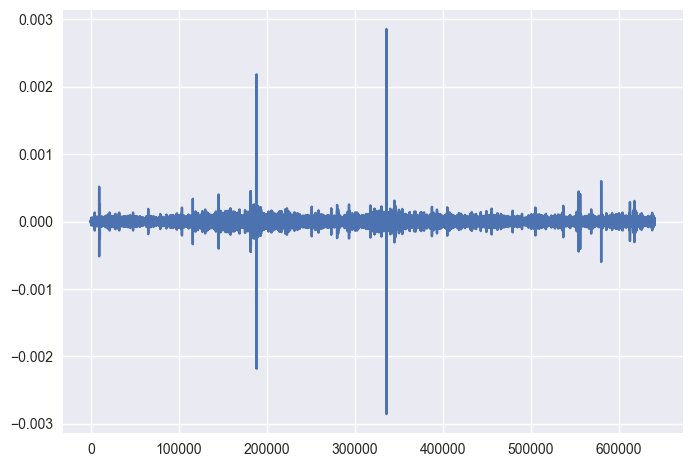

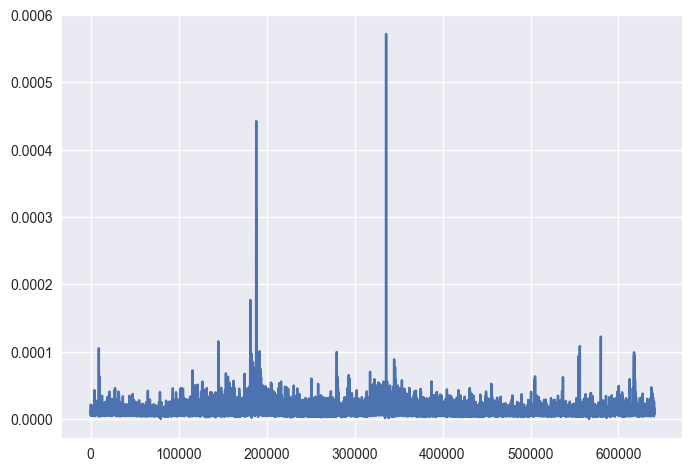

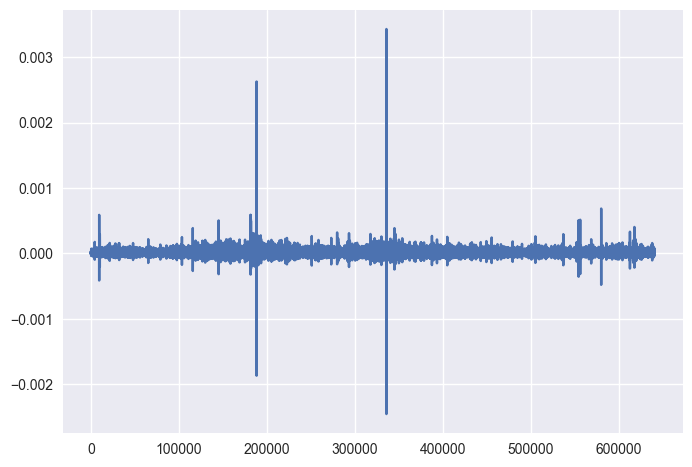

In [6]:
ind = 0
plt.plot(detail_series[ind])
plt.show()
plt.plot(vol_series[ind])
plt.show()
plt.plot(vol_series[ind]-detail_series[ind])
plt.show()

## 3. Figure 1: log-price, centered log-volatility walk, shuffled version

We now build the three time series:
- (a) log-price
- (b) centered log-volatility walk
- (c) same after shuffling the increments of log-price (as in the paper).


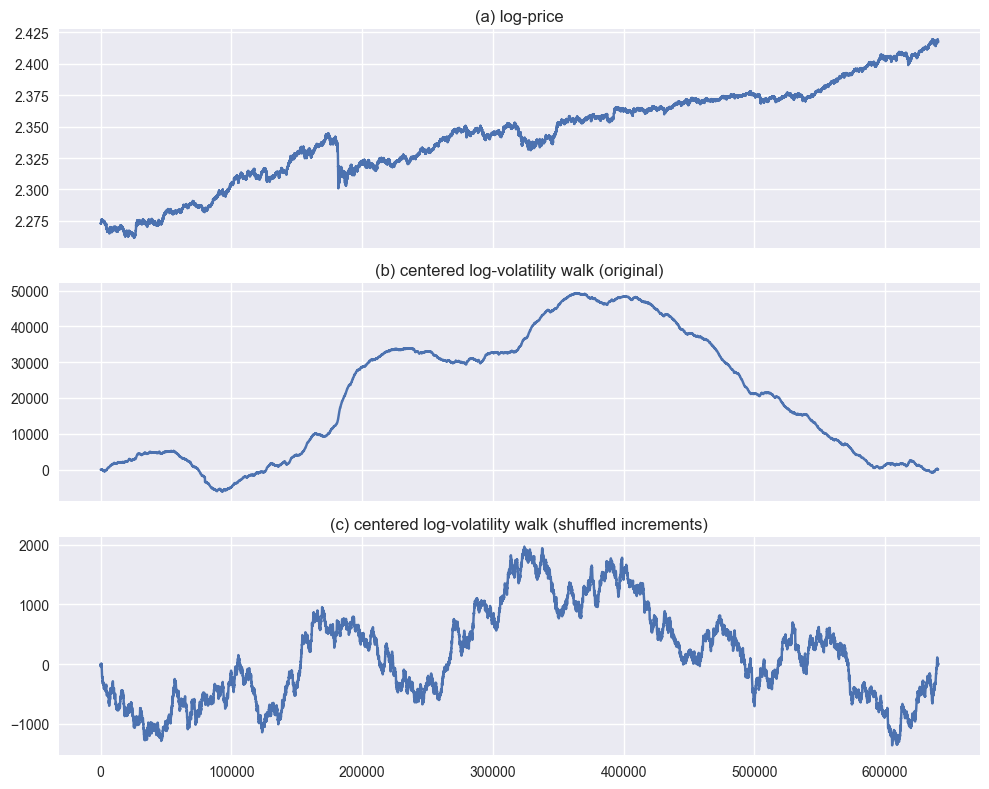

In [7]:
# (a) log-price
t = np.arange(len(df))
logP = df['log_price_deseason'].values

# (c) shuffled increments version
increments = np.diff(logP)
shuffled_increments = np.random.permutation(increments)
logP_shuffled = np.concatenate([[logP[0]], logP[0] + np.cumsum(shuffled_increments)])

# Recompute wavelet-based log-volatility walk for shuffled series
coeffs_sh = pywt.wavedec(logP_shuffled, wavelet, level=max_level)
detail_series_sh = []
for level in range(1, max_level+1):
    cD = coeffs_sh[-level]
    up = upsample_to_length(cD, level, len(logP_shuffled))
    detail_series_sh.append(up)
detail_series_sh = np.array(detail_series_sh)

vol_series_sh = []
for s_idx in range(len(scales)):
    d = detail_series_sh[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh.append(vol)
vol_series_sh = np.array(vol_series_sh)
log_vol_series_sh = np.log(vol_series_sh + 1e-12)

w_a_sh = log_vol_series_sh[scale_idx_20m]
w_a_sh_centered = w_a_sh - np.mean(w_a_sh)
v_a_sh = np.cumsum(w_a_sh_centered)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, logP)
axes[0].set_title('(a) log-price')

axes[1].plot(t, v_a)
axes[1].set_title('(b) centered log-volatility walk (original)')

axes[2].plot(t, v_a_sh)
axes[2].set_title('(c) centered log-volatility walk (shuffled increments)')

plt.tight_layout()
plt.show()


## 4. Autocorrelation of returns vs log-volatility

### Figure 1′: Autocorrelations (returns and log-volatility)

We compute:
- (a′) autocorrelation of 1-step returns
- (b′) autocorrelation of log-volatility at scale ~20 min
- (c′) same for shuffled series


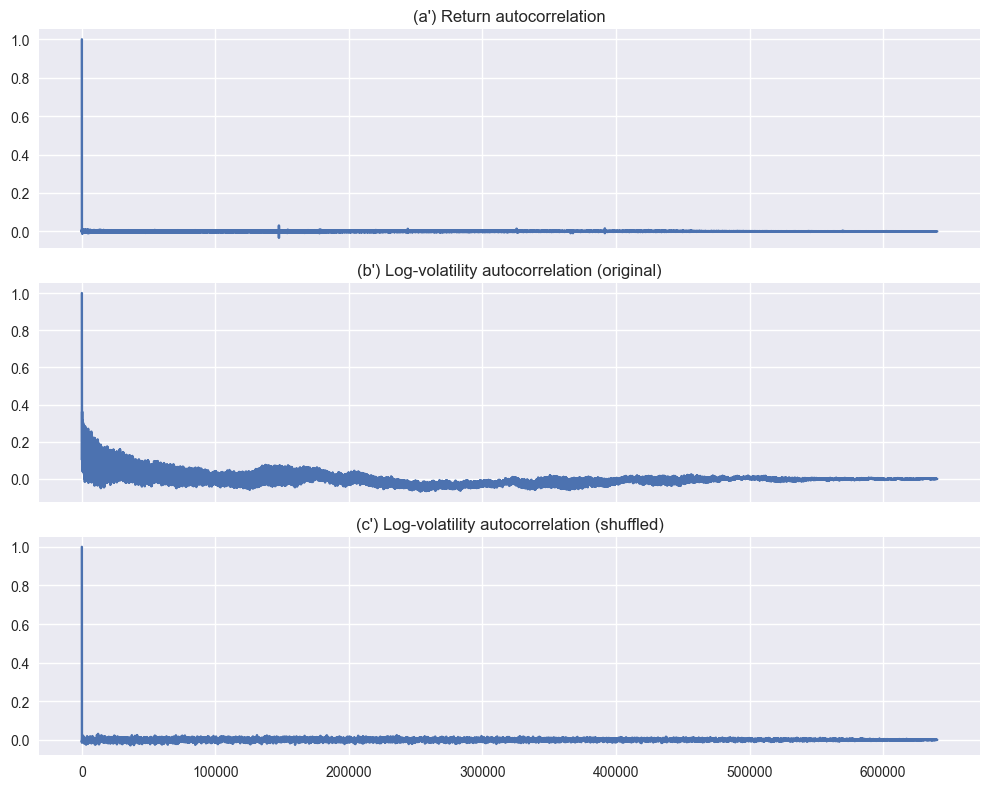

In [8]:
from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

def corr_function(x, max_lag):
    """
    Normalized autocorrelation function C(Δt) for a 1D series x,
    for lags 0..max_lag.
    """
    x = np.asarray(x, float)
    n = len(x)

    # raw autocovariance via FFT convolution
    c = covariance_fft(x)

    # unbiased normalization by number of overlapping points
    norm = np.arange(n, 0, -1)
    c = c / norm

    # normalize to get correlation function: C(0) = 1
    c = c / c[0]

    return c[:max_lag + 1]

def autocorr(x, max_lag):
    x = x - np.mean(x)
    var = np.var(x)
    ac = []
    for lag in range(max_lag+1):
        if lag == 0:
            ac.append(1.0)
        else:
            ac.append(np.dot(x[:-lag], x[lag:]) / ((len(x)-lag)*var))
    return np.array(ac)

max_lag = 500

# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = w_a
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = w_a_sh
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ret_ac)
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac)
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac)
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()


## 4. Figure 2: Log-volatility correlation vs log-lag for several scales(TODO - wrong figure)

We:
- Choose several scales (e.g. small, medium, large)
- Compute autocorrelation of log-volatility at each scale
- Plot correlation vs \\(\\ln \\Delta t\\) and show the collapse.


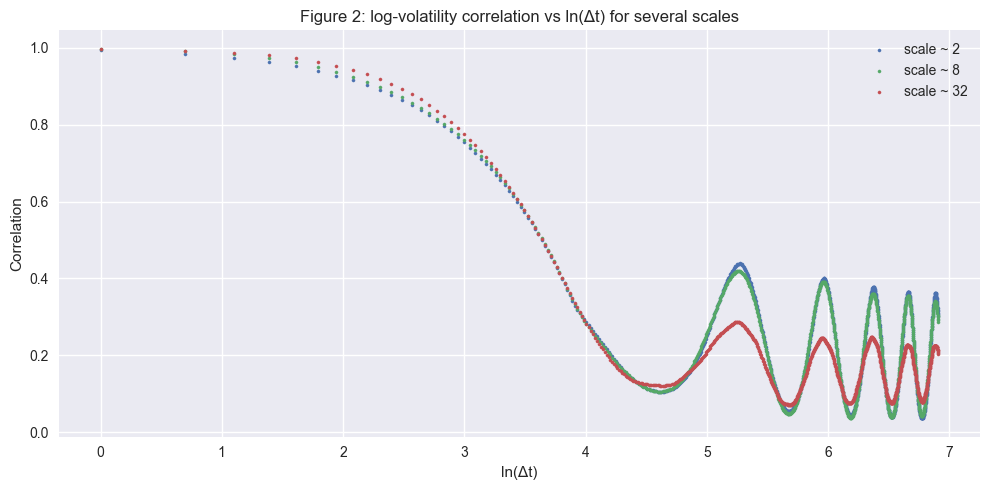

In [9]:
# Choose a few scale indices (adjust depending on your sampling)
scale_indices = [0, 2, 4]  # example: smaller, medium, larger scales
labels = [f'scale ~ {scales[i]}' for i in scale_indices]

max_lag_fig2 = 1000
lags = np.arange(1, max_lag_fig2+1)

plt.figure(figsize=(10, 5))
for idx, lab in zip(scale_indices, labels):
    w_s = log_vol_series[idx]          # this is ω_a(t)
    C = corr_function(w_s,max_lag_fig2)
    # skip lag 0, plot Δt = 1..max_lag
    plt.scatter(np.log(lags), C[1:], s=5, label=lab)

plt.xlabel('ln(Δt)')
plt.ylabel('Correlation')
plt.title('Figure 2: log-volatility correlation vs ln(Δt) for several scales')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Figure 3: Mutual information cone across time and scale (TODO - doesn't seem to show what was shown in the paper)

We compute the mutual information between log-volatility at different scales and times, using the Gaussian approximation:

\

\[
I = -\\frac{1}{2} \\log(1 - \\rho^2),
\\]



where \\(\\rho\\) is the Pearson correlation.


scale 2
time -50
time -49
time -48
time -47
time -46
time -45
time -44
time -43
time -42
time -41
time -40
time -39
time -38
time -37
time -36
time -35
time -34
time -33
time -32
time -31
time -30
time -29
time -28
time -27
time -26
time -25
time -24
time -23
time -22
time -21
time -20
time -19
time -18
time -17
time -16
time -15
time -14
time -13
time -12
time -11
time -10
time -9
time -8
time -7
time -6
time -5
time -4
time -3
time -2
time -1
time 0
time 1
time 2
time 3
time 4
time 5
time 6
time 7
time 8
time 9
time 10
time 11
time 12
time 13
time 14
time 15
time 16
time 17
time 18
time 19
time 20
time 21
time 22
time 23
time 24
time 25
time 26
time 27
time 28
time 29
time 30
time 31
time 32
time 33
time 34
time 35
time 36
time 37
time 38
time 39
time 40
time 41
time 42
time 43
time 44
time 45
time 46
time 47
time 48
time 49
time 50
scale 4
time -50
time -49
time -48
time -47
time -46
time -45
time -44
time -43
time -42
time -41
time -40
time -39
time -38
time -37
time -36
time -35
t

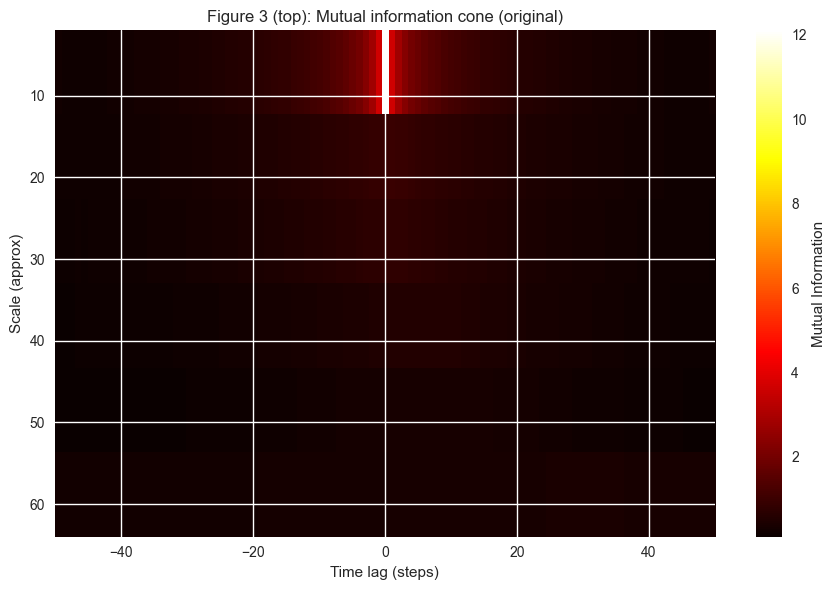

In [10]:
from sklearn.feature_selection import mutual_info_regression
def gaussian_MI(x, y):
    r, _ = pearsonr(x, y)
    r = np.clip(r, -0.999999, 0.999999)
    return -0.5 * np.log(1 - r**2)

max_time_lag = 50
ref_idx = 0  # smallest scale as reference
w_ref = log_vol_series[ref_idx]

I_map = np.zeros((len(scales), 2*max_time_lag+1))

for s_idx in range(len(scales)):
    w_other = log_vol_series[s_idx]
    print(f"scale {scales[s_idx]}")
    for dt in range(-max_time_lag, max_time_lag+1):
        print(f"time {dt}")
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref[:dt or None]
        if len(x) < 10:
            I = 0
        else:
            I = mutual_info_regression(x.reshape(-1,1), y)
        I_map[s_idx, dt + max_time_lag] = I[0]

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


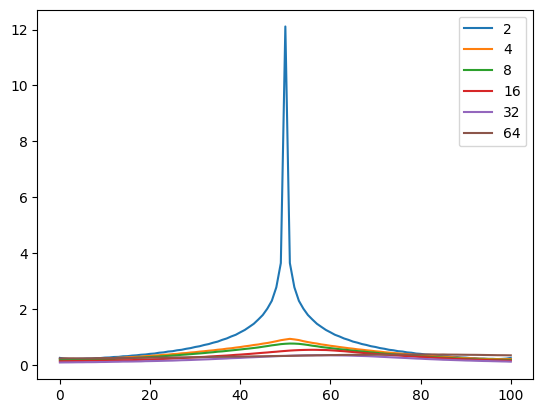

In [ ]:
scales = [2,4,8,16,32,64]
for i,I in enumerate(I_map):
    plt.plot(I,label=scales[i])
plt.legend()
plt.show()

### Shuffled control for Figure 3 (TODO)

We repeat the mutual information computation for the shuffled series, which should destroy the cascade structure and yield a noisy, structureless map.


In [ ]:
logP_shuffled2 = logP_shuffled  # from earlier
coeffs_sh2 = pywt.wavedec(logP_shuffled2, wavelet, level=max_level)

detail_series_sh2 = []
for level in range(1, max_level+1):
    cD = coeffs_sh2[-level]
    up = upsample_to_length(cD, level, len(logP_shuffled2))
    detail_series_sh2.append(up)
detail_series_sh2 = np.array(detail_series_sh2)

vol_series_sh2 = []
for s_idx in range(len(scales)):
    d = detail_series_sh2[s_idx]
    sq = d**2
    vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
    vol_series_sh2.append(vol)
vol_series_sh2 = np.array(vol_series_sh2)
log_vol_series_sh2 = np.log(vol_series_sh2 + 1e-12)

w_ref_sh = log_vol_series_sh2[ref_idx]
I_map_sh = np.zeros((len(scales), 2*max_time_lag+1))

for s_idx in range(len(scales)):
    w_other = log_vol_series_sh2[s_idx]
    for dt in range(-max_time_lag, max_time_lag+1):
        if dt >= 0:
            x = w_other[:-dt or None]
            y = w_ref_sh[dt:]
        else:
            x = w_other[-dt:]
            y = w_ref_sh[:dt or None]
        if len(x) < 10:
            I = 0
        else:
            I = gaussian_MI(x, y)
        I_map_sh[s_idx, dt + max_time_lag] = I

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map_sh, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (bottom): Mutual information cone (shuffled)')
plt.tight_layout()
plt.show()
